In [1]:
import pandas as pd
df=pd.read_csv("amazon_sales_dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  str    
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  str    
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  str    
 8   payment_method    50000 non-null  str    
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 5.0 MB


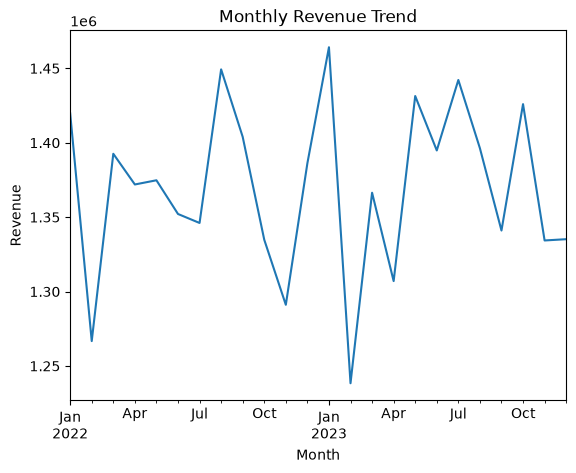

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("amazon_sales_dataset.csv")

# Convert date
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract month
df['month'] = df['order_date'].dt.to_period('M')

# Monthly revenue
monthly_sales = df.groupby('month')['total_revenue'].sum()

# Plot

monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.savefig("Image Amazon sales data/Monthly_Revenue_Trend.png")
plt.show()

In [4]:
top_categories = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)
print(top_categories.head(10))

product_category
Beauty            5550624.97
Books             5484863.03
Fashion           5480123.34
Home & Kitchen    5473132.55
Electronics       5470594.03
Sports            5407235.82
Name: total_revenue, dtype: float64


Above were top cateogaries


In [6]:
top_products = df.groupby('product_id')['total_revenue'].sum().sort_values(ascending=False)
print(top_products.head(10))

product_id
1931    18885.83
1087    18531.52
1328    18306.73
3537    18071.02
2837    17855.07
1266    17819.13
4386    17806.08
4264    17803.51
3700    17619.14
3377    17201.38
Name: total_revenue, dtype: float64


In [ ]:
Top selling Product

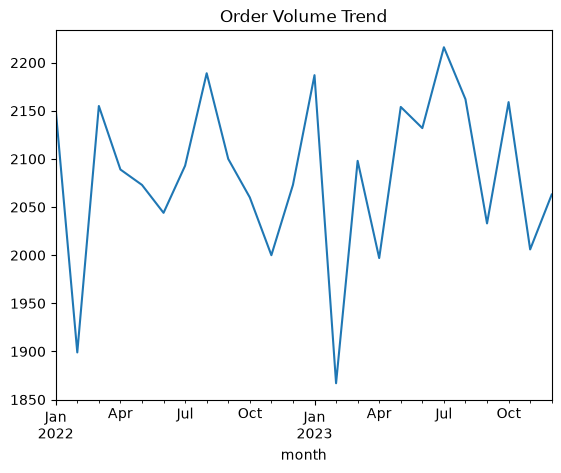

In [12]:
orders_trend = df.groupby('month')['order_id'].count()
orders_trend.plot()
plt.title("Order Volume Trend")
plt.savefig("Image Amazon sales data/Order Volume Trend.png")
plt.show()

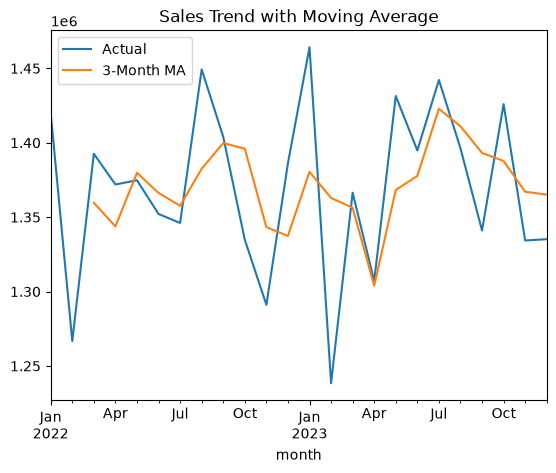

In [13]:
monthly_sales_ma = monthly_sales.rolling(window=3).mean()

monthly_sales.plot(label='Actual')
monthly_sales_ma.plot(label='3-Month MA')

plt.legend()
plt.title("Sales Trend with Moving Average")
plt.savefig("Image Amazon sales data/Sales Trend with MA.png")
plt.show()